# NB02 · Exploratory Data Analysis

**Goal:** Inspect the 20 000-row sample for data quality, visualize class and text-length distributions, audit CFPB redaction patterns, and document statistical findings that inform preprocessing and modelling choices.

| Detail | Value |
|---|---|
| Input | `data/processed/sample_complaints.csv` |
| Environment | Local CPU |
| Expected runtime | < 2 minutes |
| Outputs | 3 PNG figures in `outputs/figures/` |

## 2.1 Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH   = "../data/processed/sample_complaints.csv"
OUTPUT_DIR  = "../outputs/figures"
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:")
for col in df.columns:
    nn = df[col].notna().sum()
    print(f"  {col:<45s}  {str(df[col].dtype):<10}  {nn:,} non-null")

Shape:   20,000 rows × 6 columns

Columns:
  narrative                                      str         20,000 non-null
  product                                        str         20,000 non-null
  product_raw                                    str         20,000 non-null
  issue                                          str         20,000 non-null
  company_response                               str         20,000 non-null
  word_count                                     int64       20,000 non-null


## 2.2 Data Quality Check

Verify that the sample produced by NB01 contains no null values in any column.

In [2]:
null_df = (
    df.isnull()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
)

print(f"{'Column':<45s}  {'Nulls':>7s}  {'%':>6s}")
print("-" * 62)
for col, row in null_df.iterrows():
    print(f"  {col:<43s}  {int(row['null_count']):>7,}  {row['pct']:>5.2f}%")

total_nulls = int(null_df["null_count"].sum())
print(f"\nTotal nulls across all columns: {total_nulls}")
assert total_nulls == 0, f"Unexpected nulls found: {total_nulls}"
print("✓ Zero nulls confirmed — sample is clean")

Column                                           Nulls       %
--------------------------------------------------------------
  narrative                                          0   0.00%
  product                                            0   0.00%
  product_raw                                        0   0.00%
  issue                                              0   0.00%
  company_response                                   0   0.00%
  word_count                                         0   0.00%

Total nulls across all columns: 0
✓ Zero nulls confirmed — sample is clean


## 2.3 CFPB Redaction Audit

The CFPB replaces personally identifiable information with `XXXX`, `XX/XX/XXXX`, and `XXXXXXXX` patterns before publishing narratives. Understanding the frequency and style of these redactions is essential because they will appear as noise tokens during modelling.

Narratives with ≥ 1 redaction: 14,222 / 20,000 (71.1%)
Narratives with 0 redactions:  5,778

Statistic                    Value
-----------------------------------
  Mean                         9.3
  Median                         4
  Max                          269
  Std                         17.5


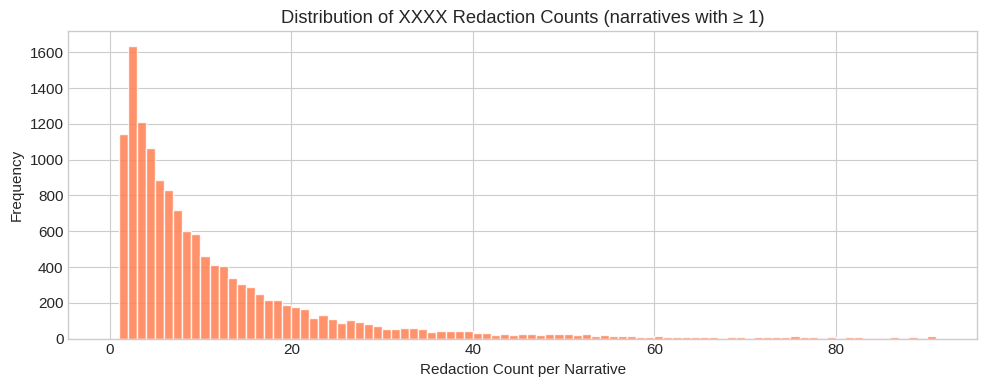


Example redacted narrative (first 500 chars):

  Product:    Debt collection
  Redactions: 8
  Text:       In XXXX of 2024 I received a notice from a company called Cedars stating I owed {$240.00} to XXXX. I wrote back asking for proof and supplied proof that the product I allegedly bought from them ( 2 sets of dishes ) I actually bought from XXXX. They wrote back and sent me an invoice allegedly from XXXX that shows {$0.00} due. Nothing makes sense- since then I have written multiple times, no response. FOR 35+ YEARS, my entire adult life, I have never been late on a payment or not paid for somethin...


In [3]:
redaction_pattern = re.compile(r"X{2,}")

df["redaction_count"] = df["narrative"].apply(lambda t: len(redaction_pattern.findall(t)))
df["has_redaction"]   = df["redaction_count"] > 0

total_with  = df["has_redaction"].sum()
total_pct   = total_with / len(df) * 100

print(f"Narratives with ≥ 1 redaction: {total_with:,} / {len(df):,} ({total_pct:.1f}%)")
print(f"Narratives with 0 redactions:  {len(df) - total_with:,}\n")

rc = df["redaction_count"]
print(f"{'Statistic':<25s}  {'Value':>7s}")
print("-" * 35)
print(f"  {'Mean':<23s}  {rc.mean():>7.1f}")
print(f"  {'Median':<23s}  {rc.median():>7.0f}")
print(f"  {'Max':<23s}  {rc.max():>7.0f}")
print(f"  {'Std':<23s}  {rc.std():>7.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(0, min(int(rc.quantile(0.99)) + 2, rc.max() + 2))
ax.hist(rc[rc > 0], bins=bins, color="coral", edgecolor="white", alpha=0.85)
ax.set(xlabel="Redaction Count per Narrative", ylabel="Frequency",
       title="Distribution of XXXX Redaction Counts (narratives with ≥ 1)")
plt.tight_layout()
plt.show()

print("\nExample redacted narrative (first 500 chars):\n")
sample_row = df[df["redaction_count"] >= 5].iloc[0]
print(f"  Product:    {sample_row['product']}")
print(f"  Redactions: {sample_row['redaction_count']}")
print(f"  Text:       {sample_row['narrative'][:500]}...")

## 2.4 Class Distributions

Two views: **product category** (the target for any future classifier) and **company response** (useful context for downstream analysis).

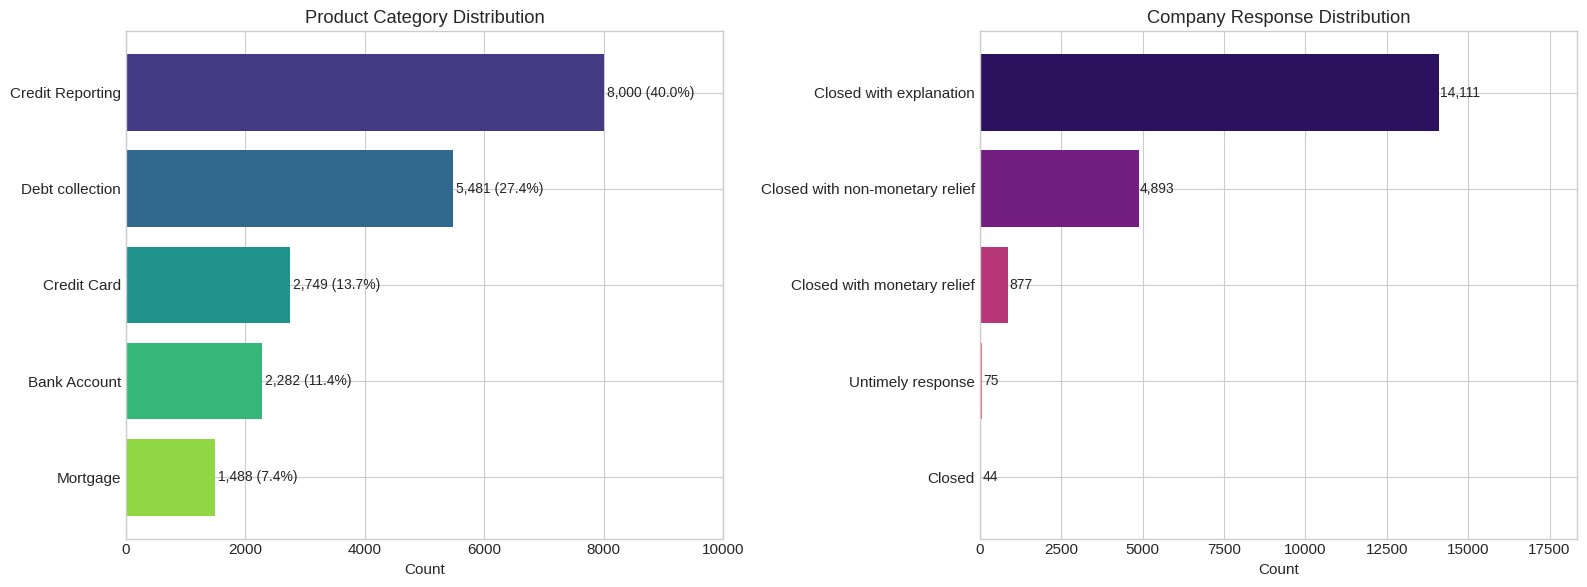


Product distribution:
  Credit Reporting            8,000  (40.0%)
  Debt collection             5,481  (27.4%)
  Credit Card                 2,749  (13.7%)
  Bank Account                2,282  (11.4%)
  Mortgage                    1,488  (7.4%)

Company response distribution:
  Closed with explanation                             14,111  (70.6%)
  Closed with non-monetary relief                      4,893  (24.5%)
  Closed with monetary relief                            877  (4.4%)
  Untimely response                                       75  (0.4%)
  Closed                                                  44  (0.2%)


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

product_counts = df["product"].value_counts()
colors_product = sns.color_palette("viridis", n_colors=len(product_counts))
ax1.barh(product_counts.index[::-1], product_counts.values[::-1], color=colors_product[::-1])
for i, (val, name) in enumerate(zip(product_counts.values[::-1], product_counts.index[::-1])):
    ax1.text(val + 50, i, f"{val:,} ({val/len(df)*100:.1f}%)", va="center", fontsize=10)
ax1.set(xlabel="Count", title="Product Category Distribution")
ax1.set_xlim(0, product_counts.max() * 1.25)

response_counts = df["company_response"].value_counts()
colors_response = sns.color_palette("magma", n_colors=len(response_counts))
ax2.barh(response_counts.index[::-1], response_counts.values[::-1], color=colors_response[::-1])
for i, (val, name) in enumerate(zip(response_counts.values[::-1], response_counts.index[::-1])):
    ax2.text(val + 30, i, f"{val:,}", va="center", fontsize=10)
ax2.set(xlabel="Count", title="Company Response Distribution")
ax2.set_xlim(0, response_counts.max() * 1.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nProduct distribution:")
for name, cnt in product_counts.items():
    print(f"  {name:<25s}  {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

print(f"\nCompany response distribution:")
for name, cnt in response_counts.items():
    print(f"  {name:<50s}  {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

## 2.5 Text Length Analysis

Word-count distribution across the sample and broken out by product category. The percentile table guides the choice of `MAX_LEN` for BERT tokenisation.

/tmp/ipykernel_20807/1343488271.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="product", x="word_count", order=product_order,


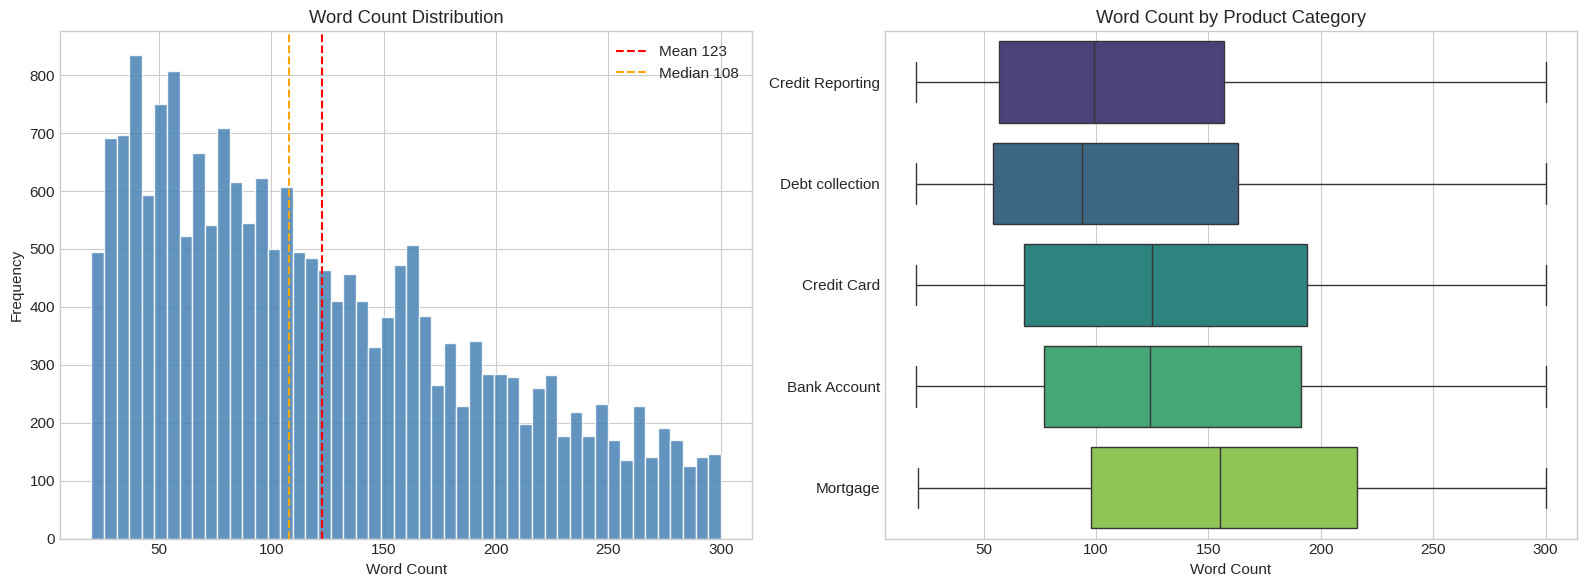


Percentile         Words
  5th                 30
  25th                 61
  50th                108
  75th                172
  95th                264
  99th                292

→ BERT MAX_LEN=128 covers median (108 words × 1.3 tokens/word ≈ 140 tokens)
→ MAX_LEN=256 needed for 95th percentile (264 words)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

wc = df["word_count"]

ax1.hist(wc, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(wc.mean(),   color="red",    linestyle="--", lw=1.5, label=f"Mean {wc.mean():.0f}")
ax1.axvline(wc.median(), color="orange", linestyle="--", lw=1.5, label=f"Median {wc.median():.0f}")
ax1.set(xlabel="Word Count", ylabel="Frequency", title="Word Count Distribution")
ax1.legend()

product_order = df["product"].value_counts().index.tolist()
sns.boxplot(data=df, y="product", x="word_count", order=product_order,
            palette="viridis", ax=ax2, fliersize=2)
ax2.set(xlabel="Word Count", ylabel="", title="Word Count by Product Category")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_word_count_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Percentile':<15}  {'Words':>7}")
for pct in [5, 25, 50, 75, 95, 99]:
    print(f"  {pct}th            {np.percentile(wc, pct):>7.0f}")
print(f"\n→ BERT MAX_LEN=128 covers median ({wc.median():.0f} words × 1.3 tokens/word ≈ "
      f"{wc.median()*1.3:.0f} tokens)")
print(f"→ MAX_LEN=256 needed for 95th percentile ({np.percentile(wc,95):.0f} words)")

## 2.6 Issue Breakdown per Product

For each of the five product categories, the top-5 most frequent **Issue** values are plotted. This reveals whether certain issues dominate a category and helps assess sub-class granularity.

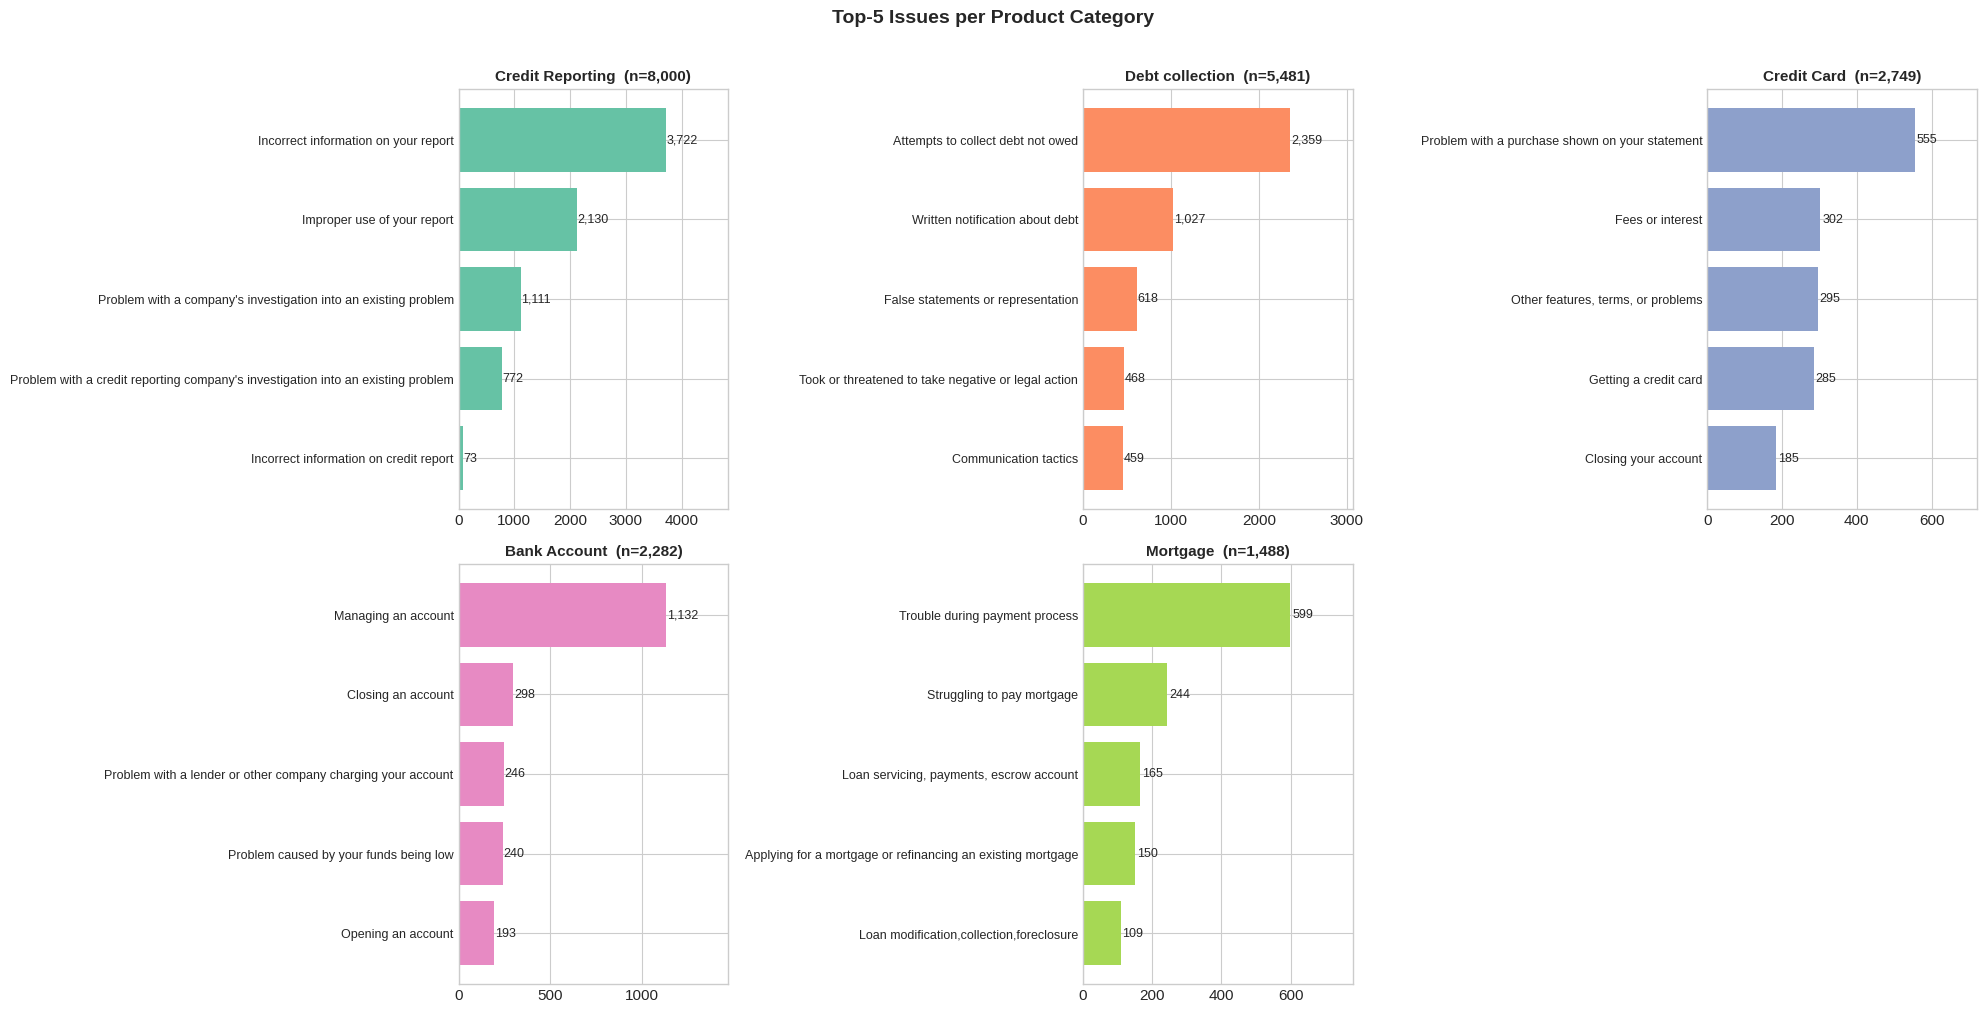

Top-5 issues per product:

  Credit Reporting
    3,722  Incorrect information on your report
    2,130  Improper use of your report
    1,111  Problem with a company's investigation into an existing problem
      772  Problem with a credit reporting company's investigation into an existing problem
       73  Incorrect information on credit report

  Debt collection
    2,359  Attempts to collect debt not owed
    1,027  Written notification about debt
      618  False statements or representation
      468  Took or threatened to take negative or legal action
      459  Communication tactics

  Credit Card
      555  Problem with a purchase shown on your statement
      302  Fees or interest
      295  Other features, terms, or problems
      285  Getting a credit card
      185  Closing your account

  Bank Account
    1,132  Managing an account
      298  Closing an account
      246  Problem with a lender or other company charging your account
      240  Problem caused by your funds

In [6]:
products = df["product"].value_counts().index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

palette = sns.color_palette("Set2", n_colors=5)

for idx, prod in enumerate(products):
    ax = axes[idx]
    subset = df[df["product"] == prod]
    top_issues = subset["issue"].value_counts().head(5)

    ax.barh(top_issues.index[::-1], top_issues.values[::-1], color=palette[idx])
    for i, val in enumerate(top_issues.values[::-1]):
        ax.text(val + 5, i, f"{val:,}", va="center", fontsize=9)
    ax.set_title(f"{prod}  (n={len(subset):,})", fontsize=11, fontweight="bold")
    ax.set_xlim(0, top_issues.max() * 1.3)
    ax.tick_params(axis="y", labelsize=9)

axes[-1].axis("off")

plt.suptitle("Top-5 Issues per Product Category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_issue_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top-5 issues per product:\n")
for prod in products:
    subset = df[df["product"] == prod]
    top5 = subset["issue"].value_counts().head(5)
    print(f"  {prod}")
    for issue, cnt in top5.items():
        print(f"    {cnt:>5,}  {issue}")
    print()

## 2.7 EDA Summary

Key findings consolidated for reference by downstream notebooks.

In [7]:
product_counts = df["product"].value_counts()
largest_cat    = product_counts.index[0]
largest_pct    = product_counts.iloc[0] / len(df) * 100
smallest_cat   = product_counts.index[-1]
smallest_pct   = product_counts.iloc[-1] / len(df) * 100

redact_pct     = df["has_redaction"].mean() * 100
mean_redact    = df.loc[df["has_redaction"], "redaction_count"].mean()

n_responses    = df["company_response"].nunique()
top_response   = df["company_response"].value_counts().index[0]
top_resp_pct   = df["company_response"].value_counts().iloc[0] / len(df) * 100

findings = f"""
{'='*70}
  NB02 — EDA SUMMARY
{'='*70}

  1. SAMPLE SIZE
     • {len(df):,} rows, {df.shape[1]} columns, zero nulls.

  2. CLASS BALANCE
     • Largest category:  {largest_cat} — {product_counts.iloc[0]:,} ({largest_pct:.1f}%)
     • Smallest category: {smallest_cat} — {product_counts.iloc[-1]:,} ({smallest_pct:.1f}%)
     • Credit Reporting capped at 40 % by design (NB01).

  3. TEXT LENGTH
     • Word count range: {int(wc.min())}–{int(wc.max())} (by construction: 20–300).
     • Median: {wc.median():.0f} words | Mean: {wc.mean():.0f} words.
     • Recommendation: BERT MAX_LEN = 128 covers the median;
       MAX_LEN = 256 covers the 95th percentile.

  4. CFPB REDACTIONS
     • {redact_pct:.1f}% of narratives contain ≥ 1 "XXXX" redaction.
     • Mean redaction count (when present): {mean_redact:.1f}.
     • Preprocessing should replace XXXX patterns with a single
       [REDACTED] token to reduce noise.

  5. COMPANY RESPONSE
     • {n_responses} unique response types.
     • Dominant: "{top_response}" ({top_resp_pct:.1f}%).

  6. ISSUE GRANULARITY
     • Each product has a distinct top-5 issue profile.
     • "Incorrect information on your report" dominates Credit Reporting.
     • Issue text may serve as an auxiliary feature in future work.

{'='*70}
  Figures saved to: {OUTPUT_DIR}/
    01_class_distributions.png
    02_word_count_analysis.png
    03_issue_breakdown.png
{'='*70}
"""

print(findings)


  NB02 — EDA SUMMARY

  1. SAMPLE SIZE
     • 20,000 rows, 8 columns, zero nulls.

  2. CLASS BALANCE
     • Largest category:  Credit Reporting — 8,000 (40.0%)
     • Smallest category: Mortgage — 1,488 (7.4%)
     • Credit Reporting capped at 40 % by design (NB01).

  3. TEXT LENGTH
     • Word count range: 20–300 (by construction: 20–300).
     • Median: 108 words | Mean: 123 words.
     • Recommendation: BERT MAX_LEN = 128 covers the median;
       MAX_LEN = 256 covers the 95th percentile.

  4. CFPB REDACTIONS
     • 71.1% of narratives contain ≥ 1 "XXXX" redaction.
     • Mean redaction count (when present): 13.0.
     • Preprocessing should replace XXXX patterns with a single
       [REDACTED] token to reduce noise.

  5. COMPANY RESPONSE
     • 5 unique response types.
     • Dominant: "Closed with explanation" (70.6%).

  6. ISSUE GRANULARITY
     • Each product has a distinct top-5 issue profile.
     • "Incorrect information on your report" dominates Credit Reporting.
     